<a href="https://colab.research.google.com/github/Molikagoela29/CustomerChurnMLProject/blob/main/AI_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, confusion_matrix



UPLOADING DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


DATA PREPROCESSING

In [ ]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869


In [ ]:
df.drop(columns=['customerID'], inplace=True)


In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce'
)
df.isnull().sum()


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df['TotalCharges'].fillna(
    df['TotalCharges'].median(), inplace=True
)


/tmp/ipython-input-2162887113.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


LABEL ENCODING


In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
print("Original dataset shape:", df.shape)
print("Feature matrix shape after encoding:", X.shape)

Original dataset shape: (7043, 20)
Feature matrix shape after encoding: (7043, 30)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.18, random_state=42
)


In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


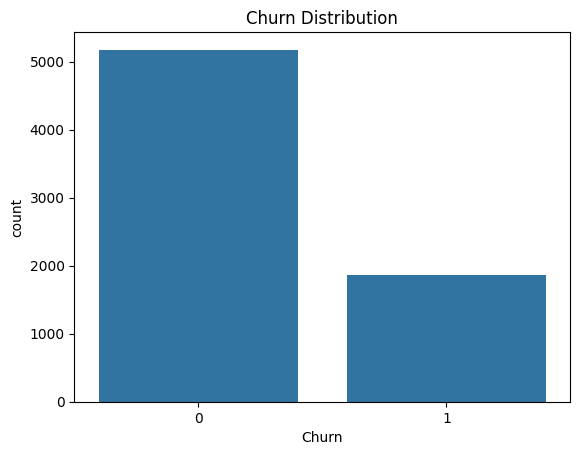

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    solver='liblinear'
)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

y_prob = lr_model.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))


Accuracy: 0.8233438485804416
ROC-AUC: 0.8656284493929068
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       933
           1       0.69      0.61      0.65       335

    accuracy                           0.82      1268
   macro avg       0.78      0.75      0.76      1268
weighted avg       0.82      0.82      0.82      1268



In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=52
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8036277602523659

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.93      0.87       933
           1       0.70      0.46      0.55       335

    accuracy                           0.80      1268
   macro avg       0.76      0.69      0.71      1268
weighted avg       0.79      0.80      0.79      1268


Confusion Matrix:

[[866  67]
 [182 153]]


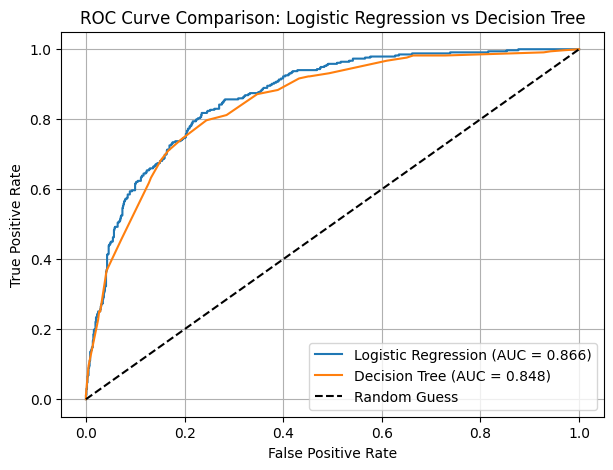

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ---------- Logistic Regression ROC ----------
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# ---------- Decision Tree ROC ----------
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

# ---------- Plot BOTH ROC Curves ----------
plt.figure(figsize=(7,5))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")

# Random guessing baseline
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Logistic Regression vs Decision Tree")
plt.legend()
plt.grid()

plt.show()

Although both models performed well, Logistic Regression achieved a higher ROC-AUC score (0.866 vs 0.848), indicating better overall class separation. Additionally, Logistic Regression provides stable probability estimates, which are essential for my retention strategy that prioritizes customers based on churn risk and expected revenue loss.

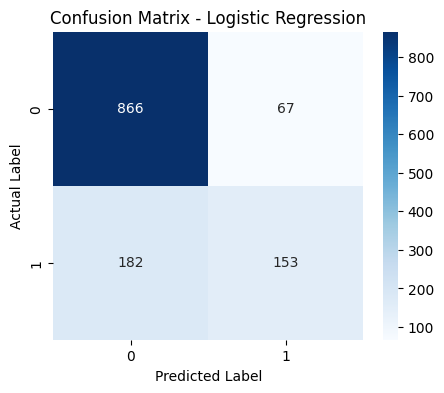

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

In [ ]:
feature_importance = pd.Series(
    lr_model.coef_[0],
    index=X.columns
)

top_features = feature_importance.reindex(
    feature_importance.abs().sort_values(ascending=False).index
)

top_features.head(10)

,0
tenure,-1.379813
TotalCharges,0.680747
Contract_Two year,-0.616552
InternetService_Fiber optic,0.554126
MonthlyCharges,-0.471854
Contract_One year,-0.268233
StreamingMovies_Yes,0.187059
OnlineSecurity_Yes,-0.169968
StreamingTV_Yes,0.165517
PaperlessBilling_Yes,0.163649


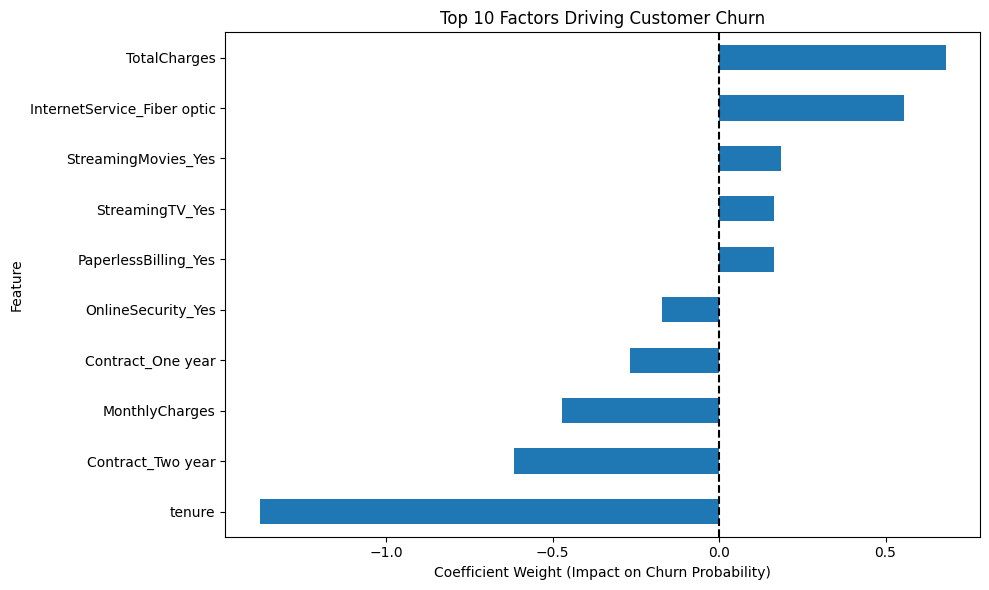

In [ ]:
# maybe
# Create coefficient series
coefficients = pd.Series(
    lr_model.coef_[0],
    index=X.columns
)

# Select top 10 features by absolute importance
top_features = coefficients.reindex(
    coefficients.abs().sort_values(ascending=False).index
).head(10)

# Sort for better visualization (negative at bottom, positive at top)
top_features = top_features.sort_values()

# Plot
plt.figure(figsize=(10,6))
top_features.plot(kind='barh')

# Add vertical reference line at 0
plt.axvline(x=0, color='black', linestyle='--')

# Labels and title
plt.title("Top 10 Factors Driving Customer Churn")
plt.xlabel("Coefficient Weight (Impact on Churn Probability)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

INNOVATION

In [ ]:
y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

results = X_test.copy()
results['Churn_Probability'] = y_prob
results['Actual_Churn'] = y_test.values

In [ ]:
EXPECTED_MONTHS = 6

results['Expected_Revenue_Loss'] = (
    results['MonthlyCharges'] * EXPECTED_MONTHS
)

In [ ]:
results['Risk_Value'] = (
    results['Churn_Probability'] *
    results['Expected_Revenue_Loss']
)

In [ ]:
DISCOUNT_COST = 300

In [ ]:
results['Offer_Incentive'] = results['Risk_Value'] > DISCOUNT_COST

In [ ]:
def retention_action(row):
    if row['Offer_Incentive']:
        if row['Churn_Probability'] > 0.75:
            return "High Priority: Personal Call + Discount"
        elif row['Churn_Probability'] > 0.5:
            return "Send Retention Offer"
    return "No Action"

results['Recommended_Action'] = results.apply(retention_action, axis=1)

In [ ]:
importance = pd.Series(
    lr_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

TotalCharges                      0.680747
InternetService_Fiber optic       0.554126
StreamingMovies_Yes               0.187059
StreamingTV_Yes                   0.165517
PaperlessBilling_Yes              0.163649
MultipleLines_Yes                 0.163200
PaymentMethod_Electronic check    0.149700
SeniorCitizen                     0.065909
MultipleLines_No phone service    0.049580
Partner_Yes                       0.020076
dtype: float64


In [ ]:
odds_ratios = pd.Series(
    np.exp(lr_model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(odds_ratios.head(10))

TotalCharges                      1.975353
InternetService_Fiber optic       1.740420
StreamingMovies_Yes               1.205698
StreamingTV_Yes                   1.180003
PaperlessBilling_Yes              1.177801
MultipleLines_Yes                 1.177273
PaymentMethod_Electronic check    1.161486
SeniorCitizen                     1.068130
MultipleLines_No phone service    1.050830
Partner_Yes                       1.020279
dtype: float64


In [ ]:
def interpret_odds(feature, value):
    if value > 1:
        increase = (value - 1) * 100
        return f"{feature}: increases churn likelihood by {increase:.1f}%"
    elif value < 1:
        decrease = (1 - value) * 100
        return f"{feature}: reduces churn likelihood by {decrease:.1f}%"
    else:
        return f"{feature}: no significant effect"

for feature, value in odds_ratios.head(8).items():
    print(interpret_odds(feature, value))

TotalCharges: increases churn likelihood by 97.5%
InternetService_Fiber optic: increases churn likelihood by 74.0%
StreamingMovies_Yes: increases churn likelihood by 20.6%
StreamingTV_Yes: increases churn likelihood by 18.0%
PaperlessBilling_Yes: increases churn likelihood by 17.8%
MultipleLines_Yes: increases churn likelihood by 17.7%
PaymentMethod_Electronic check: increases churn likelihood by 16.1%
SeniorCitizen: increases churn likelihood by 6.8%


INNOVATION 2
“I designed a retention optimization engine that combines churn probability with customer lifetime value to recommend differentiated intervention strategies.”
“Not all customers should receive incentives.
My system prioritizes high-value customers with high churn risk to maximize ROI.”

In [ ]:
results['Customer_Value'] = (
    results['MonthlyCharges'] * results['tenure']
)

In [ ]:
results['Retention_Score'] = (
    results['Churn_Probability'] *
    results['Customer_Value']
)

In [ ]:
def retention_strategy(row):

    if row['Retention_Score'] > 2200:
        return "Premium Retention: Personal Call + 20% Discount"

    elif row['Retention_Score'] > 1500:
        return "Standard Offer: 10% Discount"

    elif row['Churn_Probability'] > 0.6:
        return "Engagement Email / Loyalty Points"

    else:
        return "No Action"

results['Recommended_Action'] = results.apply(retention_strategy, axis=1)

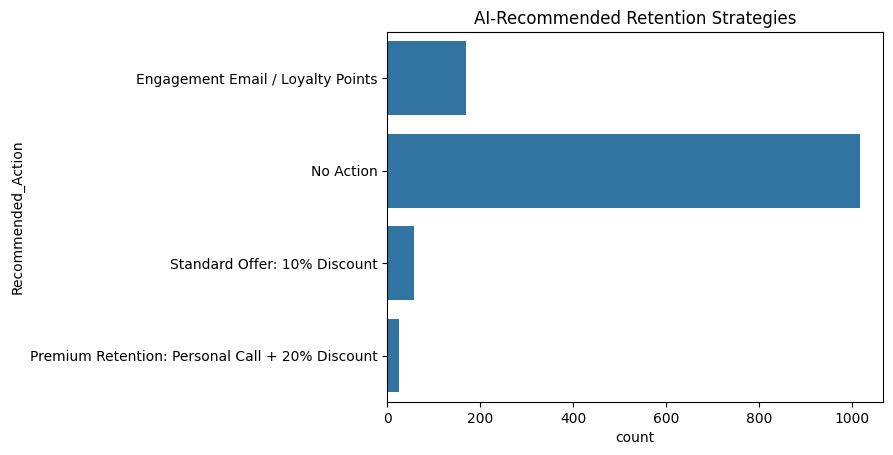

In [ ]:
sns.countplot(y='Recommended_Action', data=results)
plt.title("AI-Recommended Retention Strategies")
plt.show()

Final Conclusion
* Logistic Regression successfully predicts customer churn using demographic and service features.
* Contract duration and tenure strongly reduce churn risk.
* Fiber optic services and certain payment methods increase churn likelihood.
* A probability-based retention system enables targeted incentives instead of blanket discounts.
* The proposed approach helps optimize retention cost while maximizing customer lifetime value.